# OpERA field-processing agent
Tell it what to process in plain language → it finds the GoPro videos and GPX, checks their times line up, extracts frames, and writes GPS + echosounder depth into each JPG.

**Setup once**
1. Copy the `opera-fieldagent` folder to `MyDrive/opera-fieldagent`.
2. Add your Gemini API key as a Colab secret named `GEMINI_API_KEY` (🔑 icon, left sidebar).
3. Upload survey data to Drive, e.g. `MyDrive/OpERA/surveys/13MAY2025/` containing the GoPro `.MP4` files and the echosounder `.GPX`.

In [1]:
!pip -q install google-genai piexif

In [ ]:
# Check Gemini API key
GEMINI_API_KEY = ''

In [ ]:
import os
import sys
from dotenv import load_dotenv

# ============================================================
# Paths
# ============================================================

OPERA_ROOT = r"D:\PhilSA-OpERA\FieldProcessing\rag\opera-fieldagent-gemini\opera-fieldagent"

DATA_ROOT = os.path.join(OPERA_ROOT, "data")
DOCS_INDEX = os.path.join(OPERA_ROOT, "docs_index")

# IMPORTANT:
# Add the PARENT of the opera_agent package
sys.path.insert(0, OPERA_ROOT)

# ============================================================
# Gemini API key
# ============================================================

load_dotenv()


if not GEMINI_API_KEY:
    raise RuntimeError(
        "GEMINI_API_KEY was not found.\n"
        "Create a .env file containing:\n"
        "GEMINI_API_KEY=your_api_key"
    )

# Make available to Google Gemini libraries
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY

# ============================================================
# Import Opera Agent
# ============================================================

from opera_agent import OperaAgent

# ============================================================
# Initialize
# ============================================================

agent = OperaAgent(
    data_root=DATA_ROOT,
    docs_index=DOCS_INDEX,
    model_path=None,
    llm_model="gemini-3.1-flash-lite",
)

print("✓ Gemini API key loaded")
print("✓ OperaAgent imported")
print("✓ OperaAgent initialized")

In [4]:
import os
from dotenv import load_dotenv
from google import genai

load_dotenv()

client = genai.Client(api_key=GEMINI_API_KEY)

print("\nModels available for generateContent:")
for model in client.models.list():
    actions = getattr(model, "supported_actions", [])

    if "generateContent" in actions:
        print(model.name)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.



Models available for generateContent:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
mode

## Ask it to process

In [ ]:
print(agent.run("Check if the time range of GPX is valid with video"))

In [ ]:
print(agent.run("Process the GoPro videos from the 13MAY2025 survey, save it in result folder, and give me the geotagged images. Jus viualize the points with geotagged frame and don't include points that are outside"))

Follow-ups keep context, for example:
- `"The camera clock was on UTC — redo it."`
- `"Only recording GH0123, one frame every 2 seconds, downscaled to 1920 px wide."`
- `"Now classify the geotagged frames."` (needs `model_path`)
- `"How did the original scripts name the frames?"` (answered from the repo)

In [ ]:
print(agent.run("Show me how many frames were geotagged per recording and where the untagged ones are."))

## Look at the result

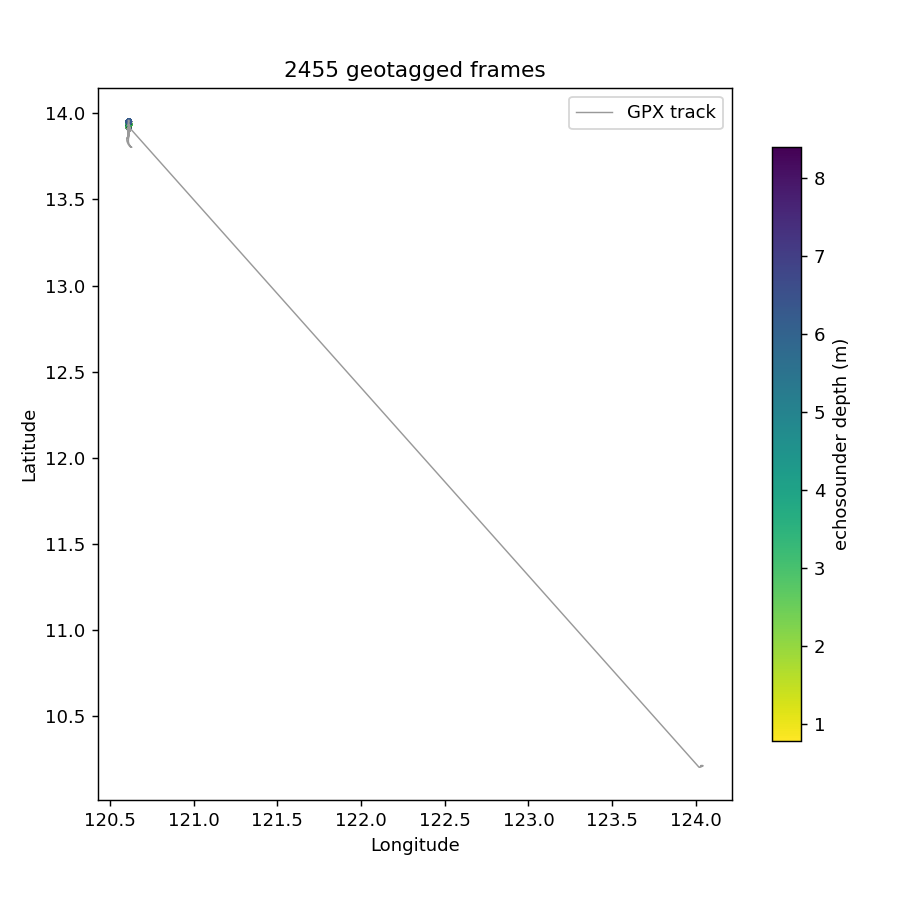

,frame_filename,recording,frame_datetime,latitude,longitude,depth_m,status,path
0,frame_2025-05-13_13-32-03.jpg,GH5091,2025-05-13T13:32:03+08:00,13.922728,120.612966,NaN,ok,D:\PhilSA-OpERA\FieldProcessing\rag\opera-fiel...
1,frame_2025-05-13_13-32-04.jpg,GH5091,2025-05-13T13:32:04+08:00,13.922730,120.612967,NaN,ok,D:\PhilSA-OpERA\FieldProcessing\rag\opera-fiel...
2,frame_2025-05-13_13-32-05.jpg,GH5091,2025-05-13T13:32:05+08:00,13.922734,120.612969,NaN,ok,D:\PhilSA-OpERA\FieldProcessing\rag\opera-fiel...
3,frame_2025-05-13_13-32-06.jpg,GH5091,2025-05-13T13:32:06+08:00,13.922736,120.612971,NaN,ok,D:\PhilSA-OpERA\FieldProcessing\rag\opera-fiel...
4,frame_2025-05-13_13-32-07.jpg,GH5091,2025-05-13T13:32:07+08:00,13.922740,120.612973,NaN,ok,D:\PhilSA-OpERA\FieldProcessing\rag\opera-fiel...


In [10]:
import pandas as pd, json
from IPython.display import Image, display
OUT = 'D:/PhilSA-OpERA/FieldProcessing/rag/opera-fieldagent-gemini/opera-fieldagent/data/13MAY2025/DCIM_processed'   # the folder the agent reported
display(Image(f'{OUT}/qa_track_map.png'))
pd.read_csv(f'{OUT}/frame_data.csv').head()

## Without the LLM (same pipeline, direct call)
Useful for batch runs or when you already know the paths and settings.

In [ ]:
from opera_agent import inspect, process_survey
VIDEOS = '/content/drive/MyDrive/OpERA/surveys/13MAY2025'
print(json.dumps(inspect(VIDEOS), indent=1, default=str))       # check overlap first
# rep = process_survey(VIDEOS, VIDEOS + '_processed', interval_s=1)